In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
print("Environment ready")


Environment ready


In [4]:
from pathlib import Path
DATA_DIR = Path("../data/raw")
files= list(DATA_DIR.glob("*"))
for file in files:
    print(file.name)

Monthly-AE-Time-Series-August-2026-YG43sd.xls


In [5]:
ae= pd.read_excel("../data/raw/Monthly-AE-Time-Series-August-2026-YG43sd.xls", sheet_name="Activity", header=13)
ae.head()

,Unnamed: 0,Period,Type 1 Departments - Major A&E,Type 2 Departments - Single Specialty,Type 3 Departments - Other A&E/Minor Injury Unit,Total Attendances,Emergency Admissions via Type 1 A&E,Emergency Admissions via Type 2 A&E,Emergency Admissions via Type 3 and 4 A&E,Total Emergency Admissions via A&E,Other Emergency Admissions (i.e not via A&E),Total Emergency Admissions,Number of patients spending >4 hours from decision to admit to admission,Number of patients spending >12 hours from decision to admit to admission,Unnamed: 14,Operational standard (Performance),Unnamed: 16,0.95
0,NaN,2010-08-01,1.138652e+06,54371.000000,559358.000000,1.752381e+06,287438.000000,5367.000000,8081.000000,300886.000000,124816.000000,425702.000000,3697.000000,1.0,NaN,0.95,NaN,NaN
1,NaN,2010-09-01,1.150728e+06,55181.000000,550359.000000,1.756268e+06,293991.000000,5543.000000,3673.000000,303207.000000,121693.000000,424900.000000,5907.000000,0.0,NaN,0.95,NaN,NaN
2,NaN,2010-10-01,1.163143e+06,54961.000000,583244.000000,1.801348e+06,303452.000000,5485.000000,2560.000000,311497.000000,124718.000000,436215.000000,6932.000000,0.0,NaN,0.95,NaN,NaN
3,NaN,2010-11-01,1.111295e+06,53727.428571,486005.428571,1.651027e+06,297832.000000,5731.142857,3279.000000,306842.142857,122256.857143,429099.000000,7179.000000,2.0,NaN,0.95,NaN,NaN
4,NaN,2010-12-01,1.159204e+06,45536.428571,533000.857143,1.737741e+06,318602.428571,6277.000000,3198.428571,328077.857143,124650.857143,452728.714286,13818.142857,15.0,NaN,0.95,NaN,NaN


In [6]:
ae.columns.tolist()

['Unnamed: 0',
 'Period',
 'Type 1 Departments - Major A&E',
 'Type 2 Departments - Single Specialty',
 'Type 3 Departments - Other A&E/Minor Injury Unit',
 'Total Attendances',
 'Emergency Admissions via Type 1 A&E',
 'Emergency Admissions via Type 2 A&E',
 'Emergency Admissions via Type 3 and 4 A&E',
 'Total Emergency Admissions via A&E',
 'Other Emergency Admissions (i.e not via A&E)',
 'Total Emergency Admissions',
 'Number of patients spending >4 hours from decision to admit to admission',
 'Number of patients spending >12 hours from decision to admit to admission',
 'Unnamed: 14',
 'Operational standard (Performance)',
 'Unnamed: 16',
 0.95]

In [7]:
ae.shape

(193, 18)

In [8]:
ae.info()

<class 'pandas.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 18 columns):
 #   Column                                                                     Non-Null Count  Dtype         
---  ------                                                                     --------------  -----         
 0   Unnamed: 0                                                                 0 non-null      float64       
 1   Period                                                                     193 non-null    datetime64[us]
 2   Type 1 Departments - Major A&E                                             193 non-null    float64       
 3   Type 2 Departments - Single Specialty                                      193 non-null    float64       
 4   Type 3 Departments - Other A&E/Minor Injury Unit                           193 non-null    float64       
 5   Total Attendances                                                          193 non-null    float64       
 6   Emergency Adm

In [9]:
#cleaning
ae=ae.dropna(axis=1, how="all")
print("Shape after removing empty columns:", ae.shape)

Shape after removing empty columns: (193, 14)


In [10]:
ae.info()

<class 'pandas.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 14 columns):
 #   Column                                                                     Non-Null Count  Dtype         
---  ------                                                                     --------------  -----         
 0   Period                                                                     193 non-null    datetime64[us]
 1   Type 1 Departments - Major A&E                                             193 non-null    float64       
 2   Type 2 Departments - Single Specialty                                      193 non-null    float64       
 3   Type 3 Departments - Other A&E/Minor Injury Unit                           193 non-null    float64       
 4   Total Attendances                                                          193 non-null    float64       
 5   Emergency Admissions via Type 1 A&E                                        193 non-null    float64       
 6   Emergency Adm

In [11]:
ae["Period"] = pd.to_datetime(ae["Period"])

In [12]:
print("Start:", ae["Period"].min())
print("End:", ae["Period"].max())

Start: 2010-08-01 00:00:00
End: 2026-08-01 00:00:00


In [13]:
ae.duplicated().sum()

np.int64(0)

In [14]:
missing=ae.isna().sum().sort_values(ascending=False)
missing

Operational standard (Performance)                                           106
Period                                                                         0
Type 2 Departments - Single Specialty                                          0
Type 3 Departments - Other A&E/Minor Injury Unit                               0
Total Attendances                                                              0
Type 1 Departments - Major A&E                                                 0
Emergency Admissions via Type 1 A&E                                            0
Emergency Admissions via Type 2 A&E                                            0
Total Emergency Admissions via A&E                                             0
Emergency Admissions via Type 3 and 4 A&E                                      0
Other Emergency Admissions (i.e not via A&E)                                   0
Total Emergency Admissions                                                     0
Number of patients spending 

In [15]:
expected_months=pd.date_range(start=ae["Period"].min(), end=ae["Period"].max(), freq="MS")
missing_months=expected_months.difference(ae["Period"])
print(len(expected_months))
print(len(ae))
print(len(missing_months))

if(len(missing_months)>0):
    print(missing_months)

193
193
0


In [16]:
ae[["Period", "Total Attendances"]].head(10)

,Period,Total Attendances
0,2010-08-01,1.752381e+06
1,2010-09-01,1.756268e+06
2,2010-10-01,1.801348e+06
3,2010-11-01,1.651027e+06
4,2010-12-01,1.737741e+06
5,2011-01-01,1.727797e+06
6,2011-02-01,1.599364e+06
7,2011-03-01,1.863441e+06
8,2011-04-01,1.844375e+06
9,2011-05-01,1.873695e+06


In [17]:
ae[["Period", "Total Attendances"]].tail(10)

,Period,Total Attendances
183,2025-11-01,2347046.0
184,2025-12-01,2326139.0
185,2026-01-01,2319296.0
186,2026-02-01,2117450.0
187,2026-03-01,2432272.0
188,2026-04-01,2345329.0
189,2026-05-01,2457398.0
190,2026-06-01,2437906.0
191,2026-07-01,2487580.0
192,2026-08-01,2342959.0


In [18]:
ae["Total Attendances"].describe()

count    1.930000e+02
mean     1.981408e+06
std      2.483261e+05
min      9.165750e+05
25%      1.832304e+06
50%      1.969691e+06
75%      2.165951e+06
max      2.487580e+06
Name: Total Attendances, dtype: float64

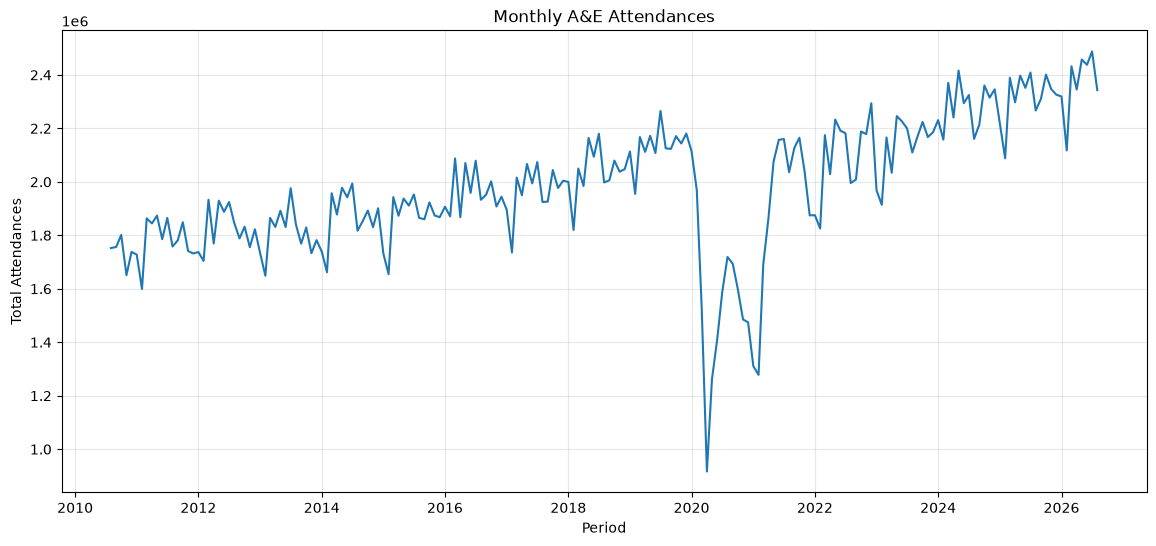

In [19]:
#graph
#EDA STARTS

plt.figure(figsize=(14, 6))
plt.plot(
    ae["Period"],
    ae["Total Attendances"],

)

plt.title("Monthly A&E Attendances")
plt.xlabel("Period")
plt.ylabel("Total Attendances")
plt.grid(alpha=0.3)

In [20]:
# Extract month information
ae["Month"] = ae["Period"].dt.month
ae["Month_Name"] = ae["Period"].dt.month_name()

monthly_seasonality = (
    ae.groupby(["Month", "Month_Name"])["Total Attendances"]
    .mean()
    .reset_index()
    .sort_values("Month")
)

monthly_seasonality

,Month,Month_Name,Total Attendances
0,1,January,1.913940e+06
1,2,February,1.812570e+06
2,3,March,2.039881e+06
3,4,April,1.927456e+06
4,5,May,2.073225e+06
5,6,June,2.036329e+06
6,7,July,2.103835e+06
7,8,August,1.970042e+06
8,9,September,1.958719e+06
9,10,October,2.022632e+06


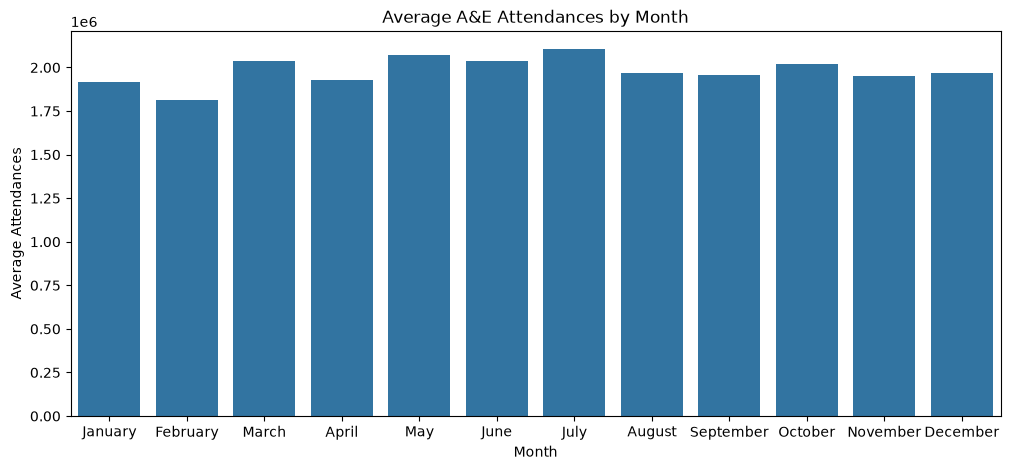

In [21]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=monthly_seasonality,
    x="Month_Name",
    y="Total Attendances"
)

plt.title("Average A&E Attendances by Month")
plt.xlabel("Month")
plt.ylabel("Average Attendances")
plt.show()

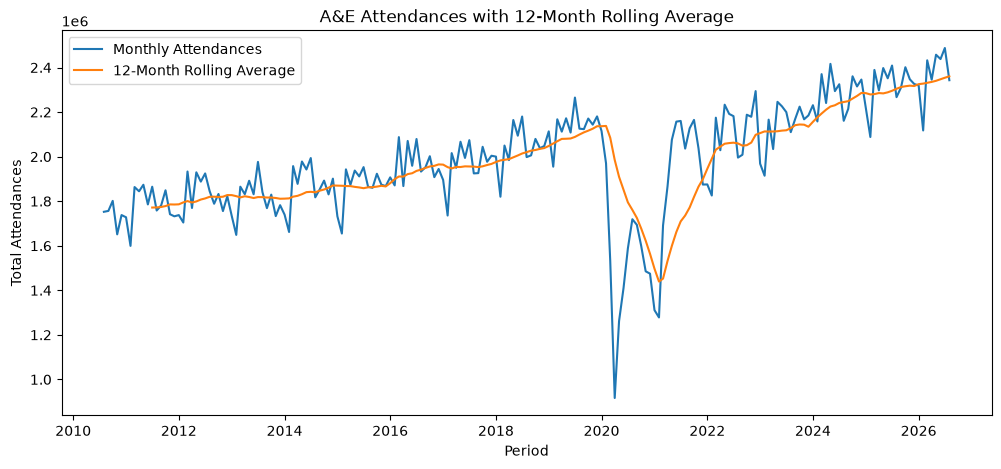

In [23]:
ae["Rolling_12M"]=(ae["Total Attendances"].rolling(window=12).mean())
plt.figure(figsize=(12, 5))
plt.plot(
    ae["Period"],
    ae["Total Attendances"],
    label="Monthly Attendances",

)
plt.plot(
    ae["Period"],
    ae["Rolling_12M"],
    label="12-Month Rolling Average",
)
plt.title("A&E Attendances with 12-Month Rolling Average")
plt.xlabel("Period")
plt.ylabel("Total Attendances")
plt.legend()
plt.show()

In [24]:
ae["Y/Y Change"] = (ae["Total Attendances"].pct_change(periods=12) * 100)
ae[["Period", "Total Attendances", "Y/Y Change"]].tail(20)

,Period,Total Attendances,Y/Y Change
173,2025-01-01,2218130.0,-0.569072
174,2025-02-01,2088071.0,-3.232472
175,2025-03-01,2389064.0,0.794989
176,2025-04-01,2297421.0,2.532861
177,2025-05-01,2397529.0,-0.776520
178,2025-06-01,2351581.0,2.507165
179,2025-07-01,2408866.0,3.614627
180,2025-08-01,2266937.0,4.912368
181,2025-09-01,2310222.0,4.335844
182,2025-10-01,2401266.0,1.725456


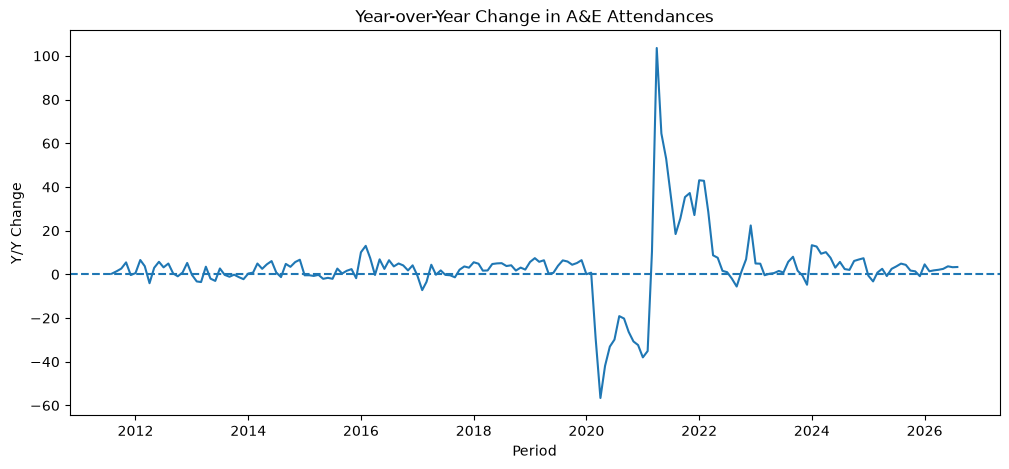

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(
    ae["Period"],
    ae["Y/Y Change"],
    label="Year by year change"
)
plt.axhline(0, linestyle="--")
plt.title("Year-over-Year Change in A&E Attendances")
plt.xlabel("Period")
plt.ylabel("Y/Y Change")
plt.show()

In [26]:
 #statsmodeling
from statsmodels.tsa.seasonal import seasonal_decompose
#its use is to decompose the time series into its components: trend, seasonality, and residuals.
ts=ae.set_index("Period")["Total Attendances"]
ts.head()

Period
2010-08-01    1.752381e+06
2010-09-01    1.756268e+06
2010-10-01    1.801348e+06
2010-11-01    1.651027e+06
2010-12-01    1.737741e+06
Name: Total Attendances, dtype: float64

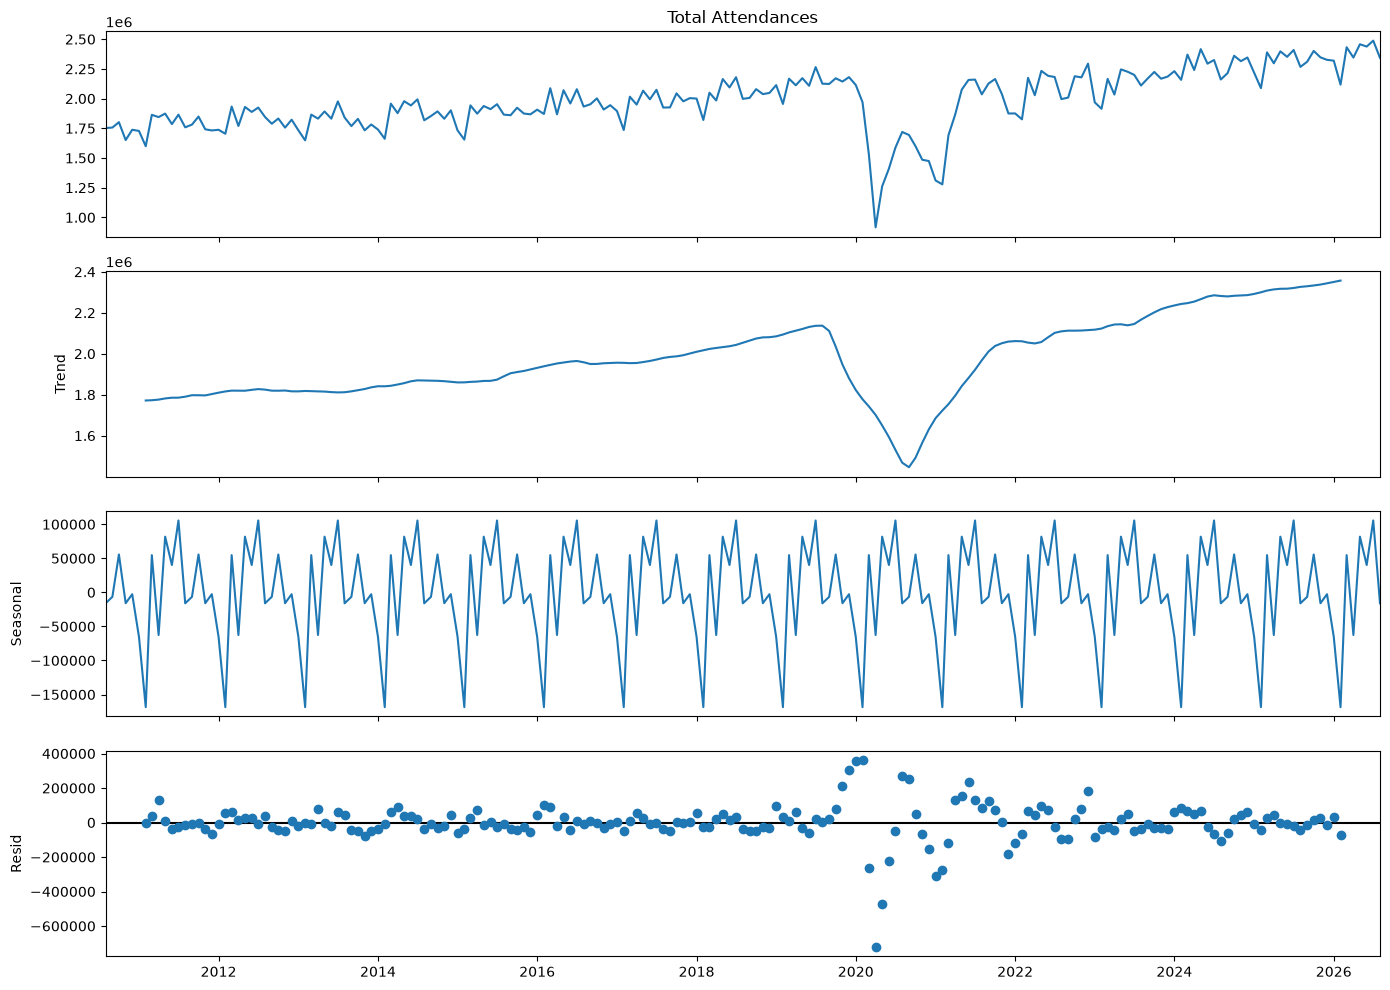

In [28]:
decomposition = seasonal_decompose(ts, model="additive", period=12)
fig=decomposition.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()